## Import the main packages, and load in the file of "good" predicted periods

In [37]:
from astropy.table import Table
from matplotlib import colors
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
import pandas as pd
import polars as pl
import pathlib
from tqdm import tqdm

In [ ]:
goldsample = pd.read_csv("(#path to#)/goldcnnsample.csv", index_col='Unnamed: 0')

## Make a function to remake the scatter plots for each individual survey

In [39]:
def comparisons_plotter(table, catalog, alias=False, save=False):
    """
    The comparison plotter function takes in a subset of predictions, cross matches the IDs to the csv file from another catalog's results
    to compare predictions across the survey range of periods.

    :param table: pd.DataFrame object that contains inferred periods from both our survey and an associated project
    :param catalog: str object to denote which survey we should be comparing with (options: 
                    'ZTF' [Lu et al. 2022], 
                    'Kbonus' [Tayar and Claytor 2025],
                    'Kepler' [Santos et al. 2019, 2021], 
                    'TESSZC' [Claytor et al. 2024], 
                    'TESSHSS' [Holcomb et al. 2022], 
                    'TESSCO' [Colman et al. 2024])
    :param alias: bool object to denote whether 90% lines should be drawn on the plot as well (Default is False)
    :param save: bool object to denote whether or not to save the figure.
    """    
    fig, axs = plt.subplots(1, 1, figsize=(6, 6))
    
    if(alias==True):
        axs.plot([0, 30*0.9], [0, 30*2], "b:")
        axs.plot([0, 30], [0, 30*0.9*2], "b:")
        axs.plot([0, 30], [0, (30*0.5)+1.5], "b:")
        axs.plot([0, 30], [0, 30*0.9*0.5], "b:")
        
    axs.plot([0, 30], [0, 30], "r--", label="1:1", alpha=0.7)
    axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", alpha=0.7)
    axs.plot([0, 30], [0, 30*0.9], "b:", alpha=0.7)
    axs.plot([0, 30], [0, 30*2], "r:",  label="2:1 and 1:2 aliases", alpha=0.7)
    axs.plot([0, 30], [0, 30*0.5], "r:", alpha=0.7)
    
    axs.set_xlim(0, 30)
    axs.set_ylim(0, 30)
    
    axs.set_xlabel('P$\\bf _{rot}$ (their work)', weight='bold')
    axs.set_ylabel('P$\\bf _{rot}$  (this work)', weight='bold')
    axs.text(1.5, 28.3, f"{len(table)} total overlap", fontweight='bold')
    period = "period"
    colorpl = 'black'
    if(catalog=="ZTF"):
        prot = "Prot"
        suptitle1 = 'Lu et al. (ZTF)'
    elif(catalog=="Kbonus"):
        prot = "Per"
        suptitle1 = 'Claytor & Tayar (Kbonus)'
    elif(catalog=="Kepler"):
        prot = "Prot"
        suptitle1 = 'Santos et al. (Kepler)'
    elif(catalog=="TESSZC"):
        prot = "prot"
        suptitle1 = 'Claytor et al. (TESS)'
    elif(catalog=="TESSCol"):
        prot = "Adjusted period"
        suptitle1 = 'Colman et al. (TESS)'
    elif(catalog=="TESSHol"):
        prot = "Prot"
        suptitle1 = 'Holcomb et al. (TESS)'
    axs.scatter(prot, period , data=table, c=colorpl, s=20, label='', rasterized=True)
    axs.set_title(suptitle1, weight="bold")
    fig.tight_layout()
    if(save==True):
        plt.savefig(f"{catalog}_compscat.pdf", dpi=300)
    plt.show()

### same function but to individually plot the subtype variables in separate scatter plots for ASAS-SN VCX

In [40]:
def comparisons_plotter_asassn(table, subtype, alias=False, save=False):
    """
    The comparison plotter function, specifically for ASAS-SN VCX compariosn, takes in a subset of predictions, 
    # cross matches the IDs to the VCX results  to compare predictions across the survey range of periods 
    
    :param table: pd.DataFrame object that contains inferred periods from both our survey and an associated project
    :param subtype: str that states the subset of the VCX that should be plotted [options are: 'ROT', 'CEP', 'EB', 
        'DSCT', 'SR', 'RRL', 'UNK', 'YSO', 'L':'spotted rotational', 'eclipsing binary-type', 'cepheid-type', 
        'delta scuti-type', 'semi-regular', 'rr lyrae-type', 'unknown variable class', 'young stellar objects, 'long irregular']
    :param alias: bool object to denote whether 90% lines should be drawn on the plot as well (Default is False)
    :param save: bool object to denote whether or not to save the figure.
    """    
    fig, axs = plt.subplots(1, 1, figsize=(6, 6))
    
    if(alias==True):
        axs.plot([0, 30*0.9], [0, 30*2], "b:")
        axs.plot([0, 30], [0, 30*0.9*2], "b:")
        axs.plot([0, 30], [0, (30*0.5)+1.5], "b:")
        axs.plot([0, 30], [0, 30*0.9*0.5], "b:")
        
    axs.plot([0, 30], [0, 30], "r--", label="1:1", alpha=0.7)
    axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", alpha=0.7)
    axs.plot([0, 30], [0, 30*0.9], "b:", alpha=0.7)
    axs.plot([0, 30], [0, 30*2], "r:",  label="2:1 and 1:2 aliases", alpha=0.7)
    axs.plot([0, 30], [0, 30*0.5], "r:", alpha=0.7)
    
    axs.set_xlim(0, 30)
    axs.set_ylim(0, 30)
    
    axs.set_xlabel('P$\\bf _{rot}$ (their work)', weight='bold')
    axs.set_ylabel('P$\\bf _{rot}$  (this work)', weight='bold')
    prot = "Period"
    period = "period"
    
    if(subtype=="ROT"):
        suptitle = "VCX Spotted Rotational Variables"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='ROT']
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='ROT']
        axs.scatter(x, y, label=suptitle, c='k',  marker="*", s=30, rasterized=True)
    elif(subtype=="EB"):
        suptitle = "VCX Eclipsing Binary-type"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="EA" or table.loc[i, 'ML_classification']=="EB" or table.loc[i, 'ML_classification']=="EW"]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="EA" or table.loc[i, 'ML_classification']=="EB" or table.loc[i, 'ML_classification']=="EW"]
        axs.scatter(x, y, label=suptitle, c='b',  marker="*", s=30, rasterized=True)
    elif(subtype=="DSCT"):
        suptitle = "VCX Delta Scuti-type"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="DSCT" or table.loc[i, 'ML_classification']=="HADS"]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="DSCT" or table.loc[i, 'ML_classification']=="HADS"] 
        axs.scatter(x, y, label=suptitle, c='maroon',  marker="*", s=30, rasterized=True)
    elif(subtype=="UNK"):
        suptitle = "VCX Unknown variable type" 
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="VAR"]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="VAR"]
        axs.scatter(x, y, label=suptitle, c='darkolivegreen',  marker="*", s=30, rasterized=True)
    elif(subtype=="SR"):
        suptitle = "VCX Semiregular Variables"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="SR"] 
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="SR"]
        axs.scatter(x, y, label=suptitle, c='saddlebrown',  marker="*", s=30, rasterized=True)
    elif(subtype=="RRL"):
        suptitle="VCX RR Lyrae-type"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="RRAB" or table.loc[i, 'ML_classification']=="RRC" or table.loc[i, 'ML_classification']=="RRD"]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=="RRAB" or table.loc[i, 'ML_classification']=="RRC" or table.loc[i, 'ML_classification']=="RRD"]
        axs.scatter(x, y, label=suptitle, c='salmon',  marker="*", s=30, rasterized=True)
    elif(subtype=="CEP"):
        suptitle = "VCX Cepheid-type"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='DCEP' or table.loc[i, 'ML_classification']=="CWA"]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='DCEP' or table.loc[i, 'ML_classification']=="CWA"]
        axs.scatter(x, y, label=suptitle, c='teal',  marker="*", s=30, rasterized=True)
    elif(subtype=="L"):
        suptitle = "VCX Long Irregular Variables"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='L' ]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='L']
        axs.scatter(x, y, label=suptitle, c='#8900F2',  marker="*", s=30, rasterized=True)
    elif(subtype=="YSO"):
        suptitle = "VCX Young Stellar Objects"
        x = [table[prot][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='YSO' ]
        y = [table[period][i] for i in range(len(table)) if table.loc[i, 'ML_classification']=='YSO']
        axs.scatter(x, y, label=suptitle, c='#009216',  marker="*", s=30, rasterized=True)
    axs.text(1.5, 28.3, f"{len(x)} total overlap", fontweight='bold')
    fig.tight_layout()
    if(save==True):
        plt.savefig(f"ASASSN_{subtype}_compscat.pdf", dpi=300)
    plt.show()

In [41]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

## Now we go catalog by catalog to make these scatterplots

### 1. Lu et al. (2022, ZTF)

In [42]:
ztf = Table.read('files/crossmatch/luztf.txt', format="ascii.cds").to_pandas().rename(columns={'EDR3':'EDR3_source_id'})

In [43]:
ztf0 = pd.merge(goldsample, ztf, on='EDR3_source_id', how='inner').drop_duplicates(subset=['gaia_id'])

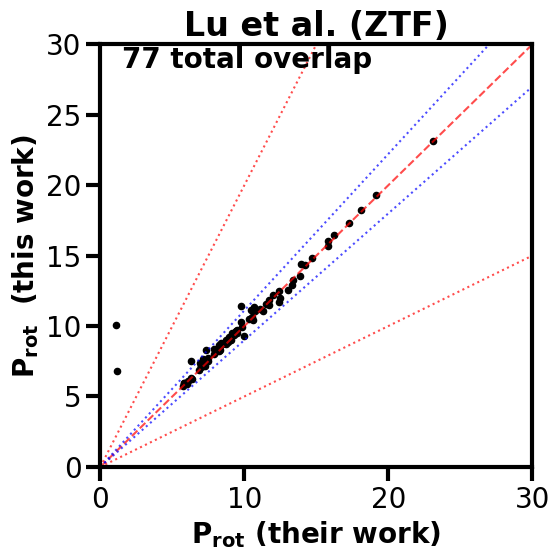

In [44]:
comparisons_plotter(ztf0, "ZTF", save=True)

### 2. Santos et al. (2019/2021, Kepler)

In [45]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()

santostot = pd.concat([santos1, santos2])

In [46]:
santos0 = pd.merge(goldsample, santostot, on='KIC', how='inner').drop_duplicates(subset=['gaia_id'])

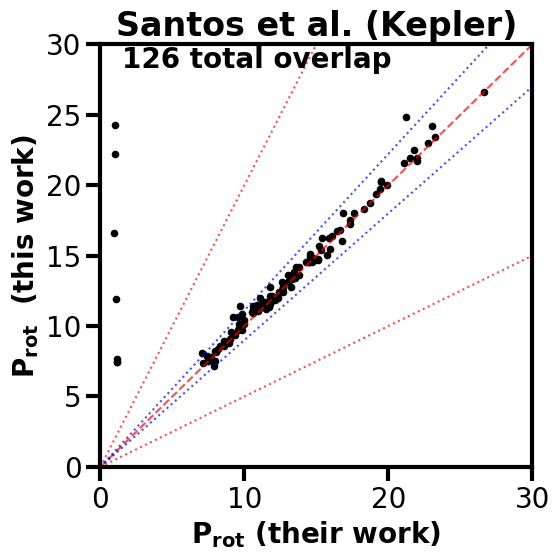

In [47]:
comparisons_plotter(santos0, "Kepler", save=True)

### 3. Claytor et al. (TESS, 2024)

In [48]:
tesszc = Table.read('files/crossmatch/claytortess.txt', format="ascii.cds").to_pandas().rename(columns={'TIC':'tic_id'})

In [49]:
tesszc0 = pd.merge(goldsample, tesszc, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])

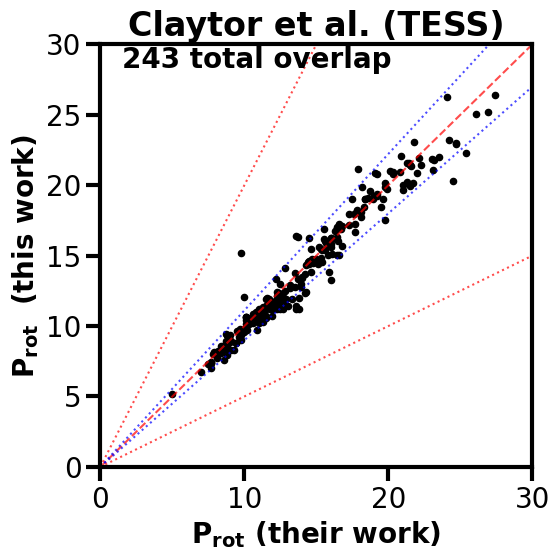

In [50]:
comparisons_plotter(tesszc0, "TESSZC", save=True)

### 4. Claytor and Tayar (Kepler Bonus, 2025)

In [51]:
kbonuszc = Table.read('files/crossmatch/claytorkbonus.txt', format="ascii.cds").to_pandas()#.rename(columns={'TIC':'tic_id'})
kbonuszc['dr3_source_id'] = kbonuszc['GaiaDR3'].map(lambda x: x.lstrip('Gaia DR3'))
kbonuszc = kbonuszc.drop('GaiaDR3', axis=1)
kbonuszc['abs_g'] = (kbonuszc['phot_g_mean_mag']+5-(5*np.log10(1000/kbonuszc['plx']))).replace([np.inf, -np.inf], np.nan)
kbonuszc['dr3_source_id'] = kbonuszc['dr3_source_id'].fillna(0).astype(np.int64)

/Users/mschochet/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [52]:
kbonuszc0 = pd.merge(goldsample, kbonuszc, on='dr3_source_id', how='inner').drop_duplicates(subset=['dr3_source_id'])

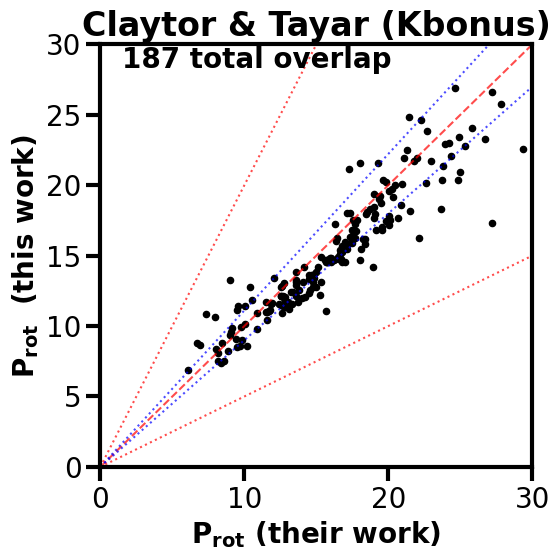

In [53]:
comparisons_plotter(kbonuszc0, "Kbonus", save=True)

### 5/6. Catalogs from Holcomb et al. (2022) and Colman et al. (2024), both TESS (these catalogs are currently not public, please contact the appropriate PI to get these files)

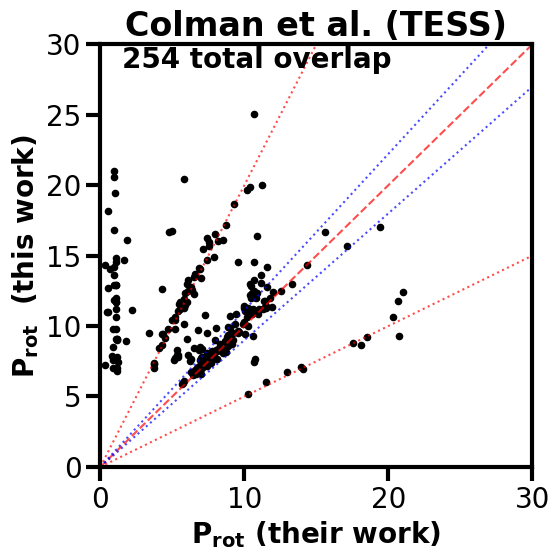

In [ ]:
colmancat = pd.read_csv('(#path to#)/colmantess.csv').drop(labels=['Unnamed: 0'], axis=1).rename(columns={'TIC':'tic_id'})
colmancat0 = pd.merge(goldsample, colmancat, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])
comparisons_plotter(colmancat0, "TESSCol")

In [ ]:
holcombcat = pd.read_csv('(#path to#)/spinspotter_by_star.csv').rename(columns={'TICID':'tic_id'})
holcombperiods = holcombcat[holcombcat['rotation_accepted']==True]

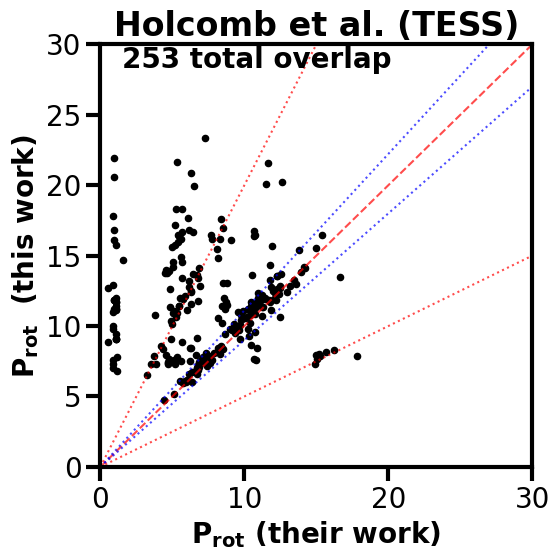

In [56]:
holcombcat0 = pd.merge(goldsample, holcombperiods, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])
comparisons_plotter(holcombcat0, "TESSHol", save=True)

### 7. Christy et al. (ASAS-SN VCX, 2021). This catalog's .csv file may be downloaded at this link: https://drive.google.com/drive/folders/1gxcIokRsw1eyPmbPZ0-C8blfRGItSOAu?usp=sharing

In [ ]:
asassn = pd.read_csv('(#path to#)/asassn_variables_x.csv')

asassn['abs_g'] = asassn['phot_g_mean_mag']+5-(5*np.log10(np.abs(1000/asassn['parallax'])))
asassn['TIC_ID'] = asassn['TIC_ID'].astype('str').map(lambda x: x.strip('TIC '))
asassn['EDR3_source_id'] = asassn['EDR3_source_id'].astype('str').map(lambda x: x.strip('EDR3 '))
asassn['EDR3_source_id'] = asassn['EDR3_source_id'].astype('int')
asassn['TIC_ID'] = asassn['TIC_ID'].astype('float')

asassn.rename(columns={'TIC_ID':'tic_id'}, inplace=True)
asassn = asassn.replace([np.inf, -np.inf], np.nan)

In [58]:
asassncross = pd.merge(goldsample, asassn, on='tic_id', how='inner', suffixes=('', '_y')).drop_duplicates(subset=['tic_id']).reset_index().drop(columns=['index'])

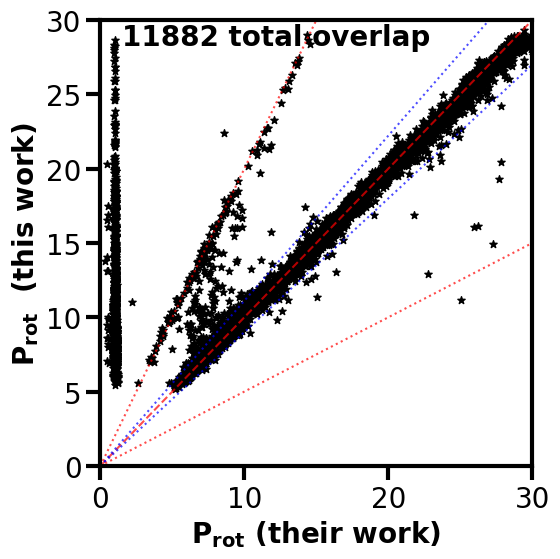

In [59]:
comparisons_plotter_asassn(asassncross, "ROT", save=True)

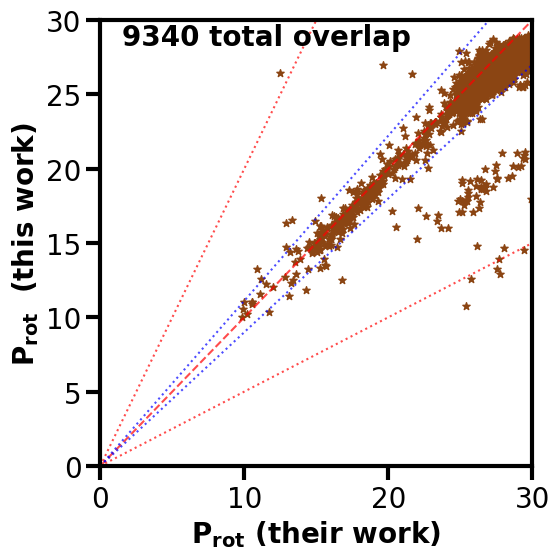

In [60]:
comparisons_plotter_asassn(asassncross, "SR", save=True)

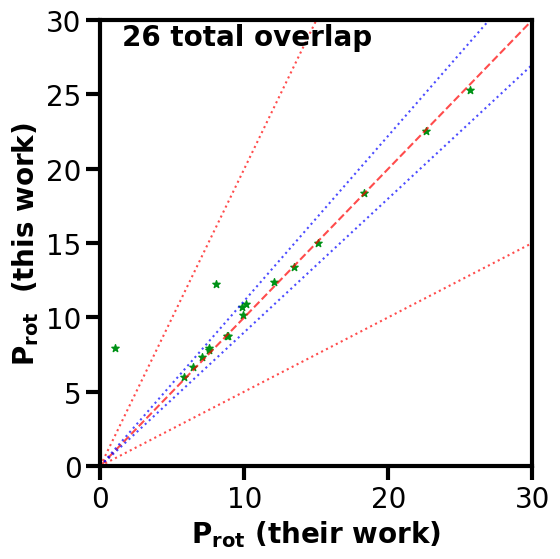

In [61]:
comparisons_plotter_asassn(asassncross, "YSO", save=True)

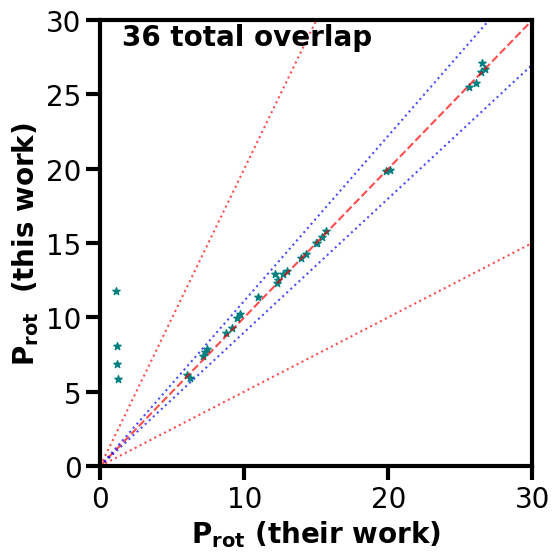

In [62]:
comparisons_plotter_asassn(asassncross, "CEP", save=True)

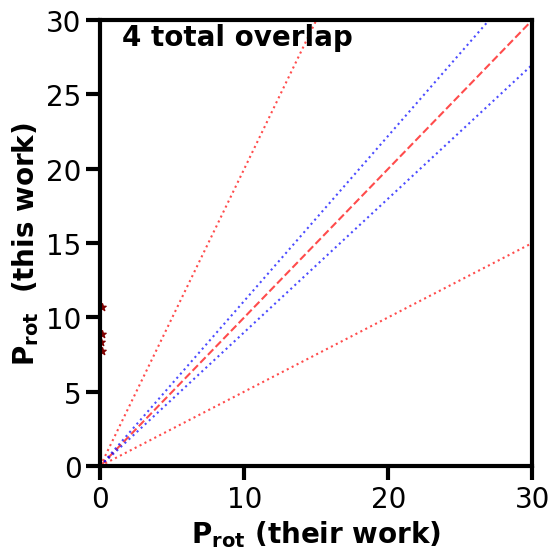

In [63]:
comparisons_plotter_asassn(asassncross, "DSCT", save=True)

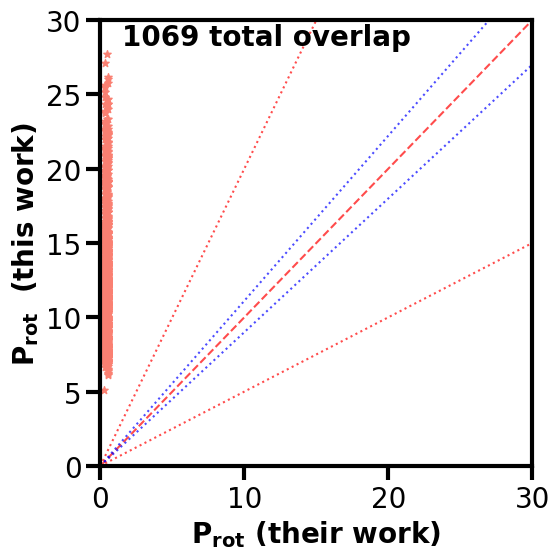

In [64]:
comparisons_plotter_asassn(asassncross, "RRL", save=True)

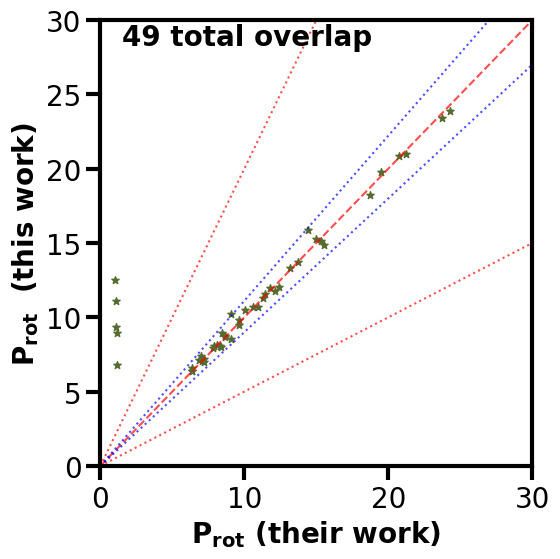

In [65]:
comparisons_plotter_asassn(asassncross, "UNK", save=True)

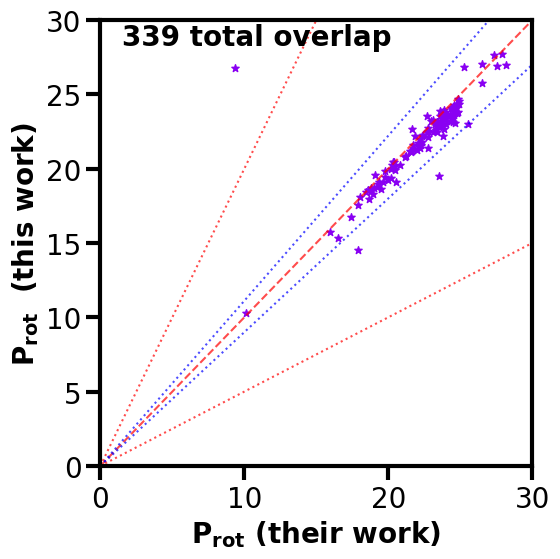

In [66]:
comparisons_plotter_asassn(asassncross, "L", save=True)

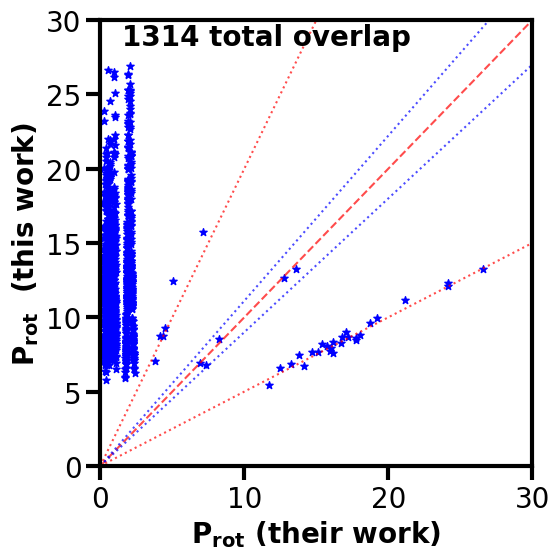

In [67]:
comparisons_plotter_asassn(asassncross, "EB", save=True)

# Combined x6 plot colored by magnitude

In [68]:
catalogs = [ztf0, kbonuszc0, santos0, holcombcat0, tesszc0, colmancat0]
ztf0['bp-rp'] = ztf0['phot_bp_mean_mag']-ztf0['phot_rp_mean_mag']
kbonuszc0['bp-rp'] = kbonuszc0['phot_bp_mean_mag_x']-kbonuszc0['phot_rp_mean_mag_x']
santos0['bp-rp'] = santos0['phot_bp_mean_mag']-santos0['phot_rp_mean_mag']
holcombcat0['bp-rp'] = holcombcat0['phot_bp_mean_mag']-holcombcat0['phot_rp_mean_mag']
tesszc0['bp-rp'] = tesszc0['phot_bp_mean_mag']-tesszc0['phot_rp_mean_mag']
colmancat0['bp-rp'] = colmancat0['phot_bp_mean_mag']-colmancat0['phot_rp_mean_mag']

In [69]:
def comparisons_plotter_6x(tables, parameter = 'bp-rp', save=False):
    """
    The comparison plotter function takes in all the compared predictions and plots them as a 3x2 image to demonstrate
    overlapping prediction accuracy and to color the objects by their absolute magnitude

    :param tables: list object of pd.DataFrame objects that contains inferred periods from both surveys
    :param parameter: string object of the DataFrame column to color the scatter plots and normalize the colorbar by 
    :param save: bool object to denote whether or not to save the figure.
    """   
    min = 0.001
    max = 0.001
    for table in tables:
        if(float(np.nanmin(table[parameter])) <= min):
            min = np.nanmin(table[parameter])
        if(float(np.nanmax(table[parameter])) >= max):
            max = np.nanmax(table[parameter])
    if(parameter=='teff_xgboost'):
        normi = colors.Normalize(3000, 6000)
    else:
        normi = colors.Normalize(min, max)

    fig, axes = plt.subplots(2, 3, figsize=(30, 18))
    
    for index, (axs, table) in enumerate(zip(axes.flat, tables)):
        axs.plot([0, 30], [0, 30], "r--", label="1:1", alpha=0.7, rasterized=True)
        axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", alpha=0.7, rasterized=True)
        axs.plot([0, 30], [0, 30*0.9], "b:", alpha=0.7, rasterized=True)
        axs.plot([0, 30], [0, 30*2], "r:",  label="2:1 and 1:2 aliases", alpha=0.7, rasterized=True)
        axs.plot([0, 30], [0, 30*0.5], "r:", alpha=0.7, rasterized=True)
        axs.set_xlim(0, 30)
        axs.set_ylim(0, 30)
        
        axs.text(1.5, 28.3, f"{len(table)} total overlap", fontweight='bold', rasterized=True)
        period = "period"
        if(index==0):
            prot = "Prot"
            suptitle1 = 'Lu et al. (ZTF)'
        elif(index==1):
            prot = "Per"
            suptitle1 = 'Claytor & Tayar (Kbonus)'
        elif(index==2):
            prot = "Prot"
            suptitle1 = 'Santos et al. (Kepler)'
        elif(index==3):
            prot = "Prot"
            suptitle1 = 'Holcomb et al. (TESS)'
        elif(index==4):
            prot = "prot"
            suptitle1 = 'Claytor et al. (TESS)'
        elif(index==5):
            prot = "Adjusted period"
            suptitle1 = 'Colman et al. (TESS)'
        pl0 = axs.scatter(prot, period, data=table, c=parameter, norm=normi, cmap='seismic', marker="*", s=150, rasterized=True)
        axs.set_title(suptitle1, weight='bold', rasterized=True)
    
    axes[0, 0].set_xlabel('(a)', weight='bold')
    axes[0, 1].set_xlabel('(b)', weight='bold')
    axes[0, 2].set_xlabel('(c)',  weight='bold')
    axes[1, 0].set_xlabel('(d)',  weight='bold')
    axes[1, 1].set_xlabel('(e)',  weight='bold')
    axes[1, 2].set_xlabel('(f)',  weight='bold')

    cbar = fig.colorbar(pl0, cmap='seismic', ax=axes,  orientation='vertical', fraction=0.15)
    if(parameter=='bp-rp'):
        cbar.set_label(label = 'Gaia $\\bf B_p - R_p$ [dex]', weight='bold')
    if(parameter=='mh_xgboost'):
        cbar.set_label(label = 'XGBoost [M/H] [dex]', weight='bold')
    if(parameter=='teff_xgboost'):
        cbar.set_label(label = 'XGBoost T$\\bf _{eff}$ [K]', weight='bold')
    if(parameter=='logg_xgboost'):
        cbar.set_label(label = 'XGBoost log(g) [dex]', weight='bold')
    if(parameter=='frac_err'):
        cbar.set_label(label = 'Fractional Error', weight='bold')
    if(parameter=='radius_val'):
        cbar.set_label(label = 'Gaia Bolometric Radius ($\\bf M_{\odot}$)', weight='bold')
    if(parameter=='lum_val'):
        cbar.set_label(label = 'Gaia Bolometric Luminosity ($\\bf L_{\odot}$)', weight='bold')
    fig.supxlabel('P$\\bf _{rot}$ (their work)', weight='bold', y=0.03)
    fig.supylabel('P$\\bf _{rot}$  (this work)', weight='bold', x=0.09)
    #plt.show()
    
    if(save==True):
        plt.savefig("color_compscat.pdf", dpi=300, bbox_inches='tight')


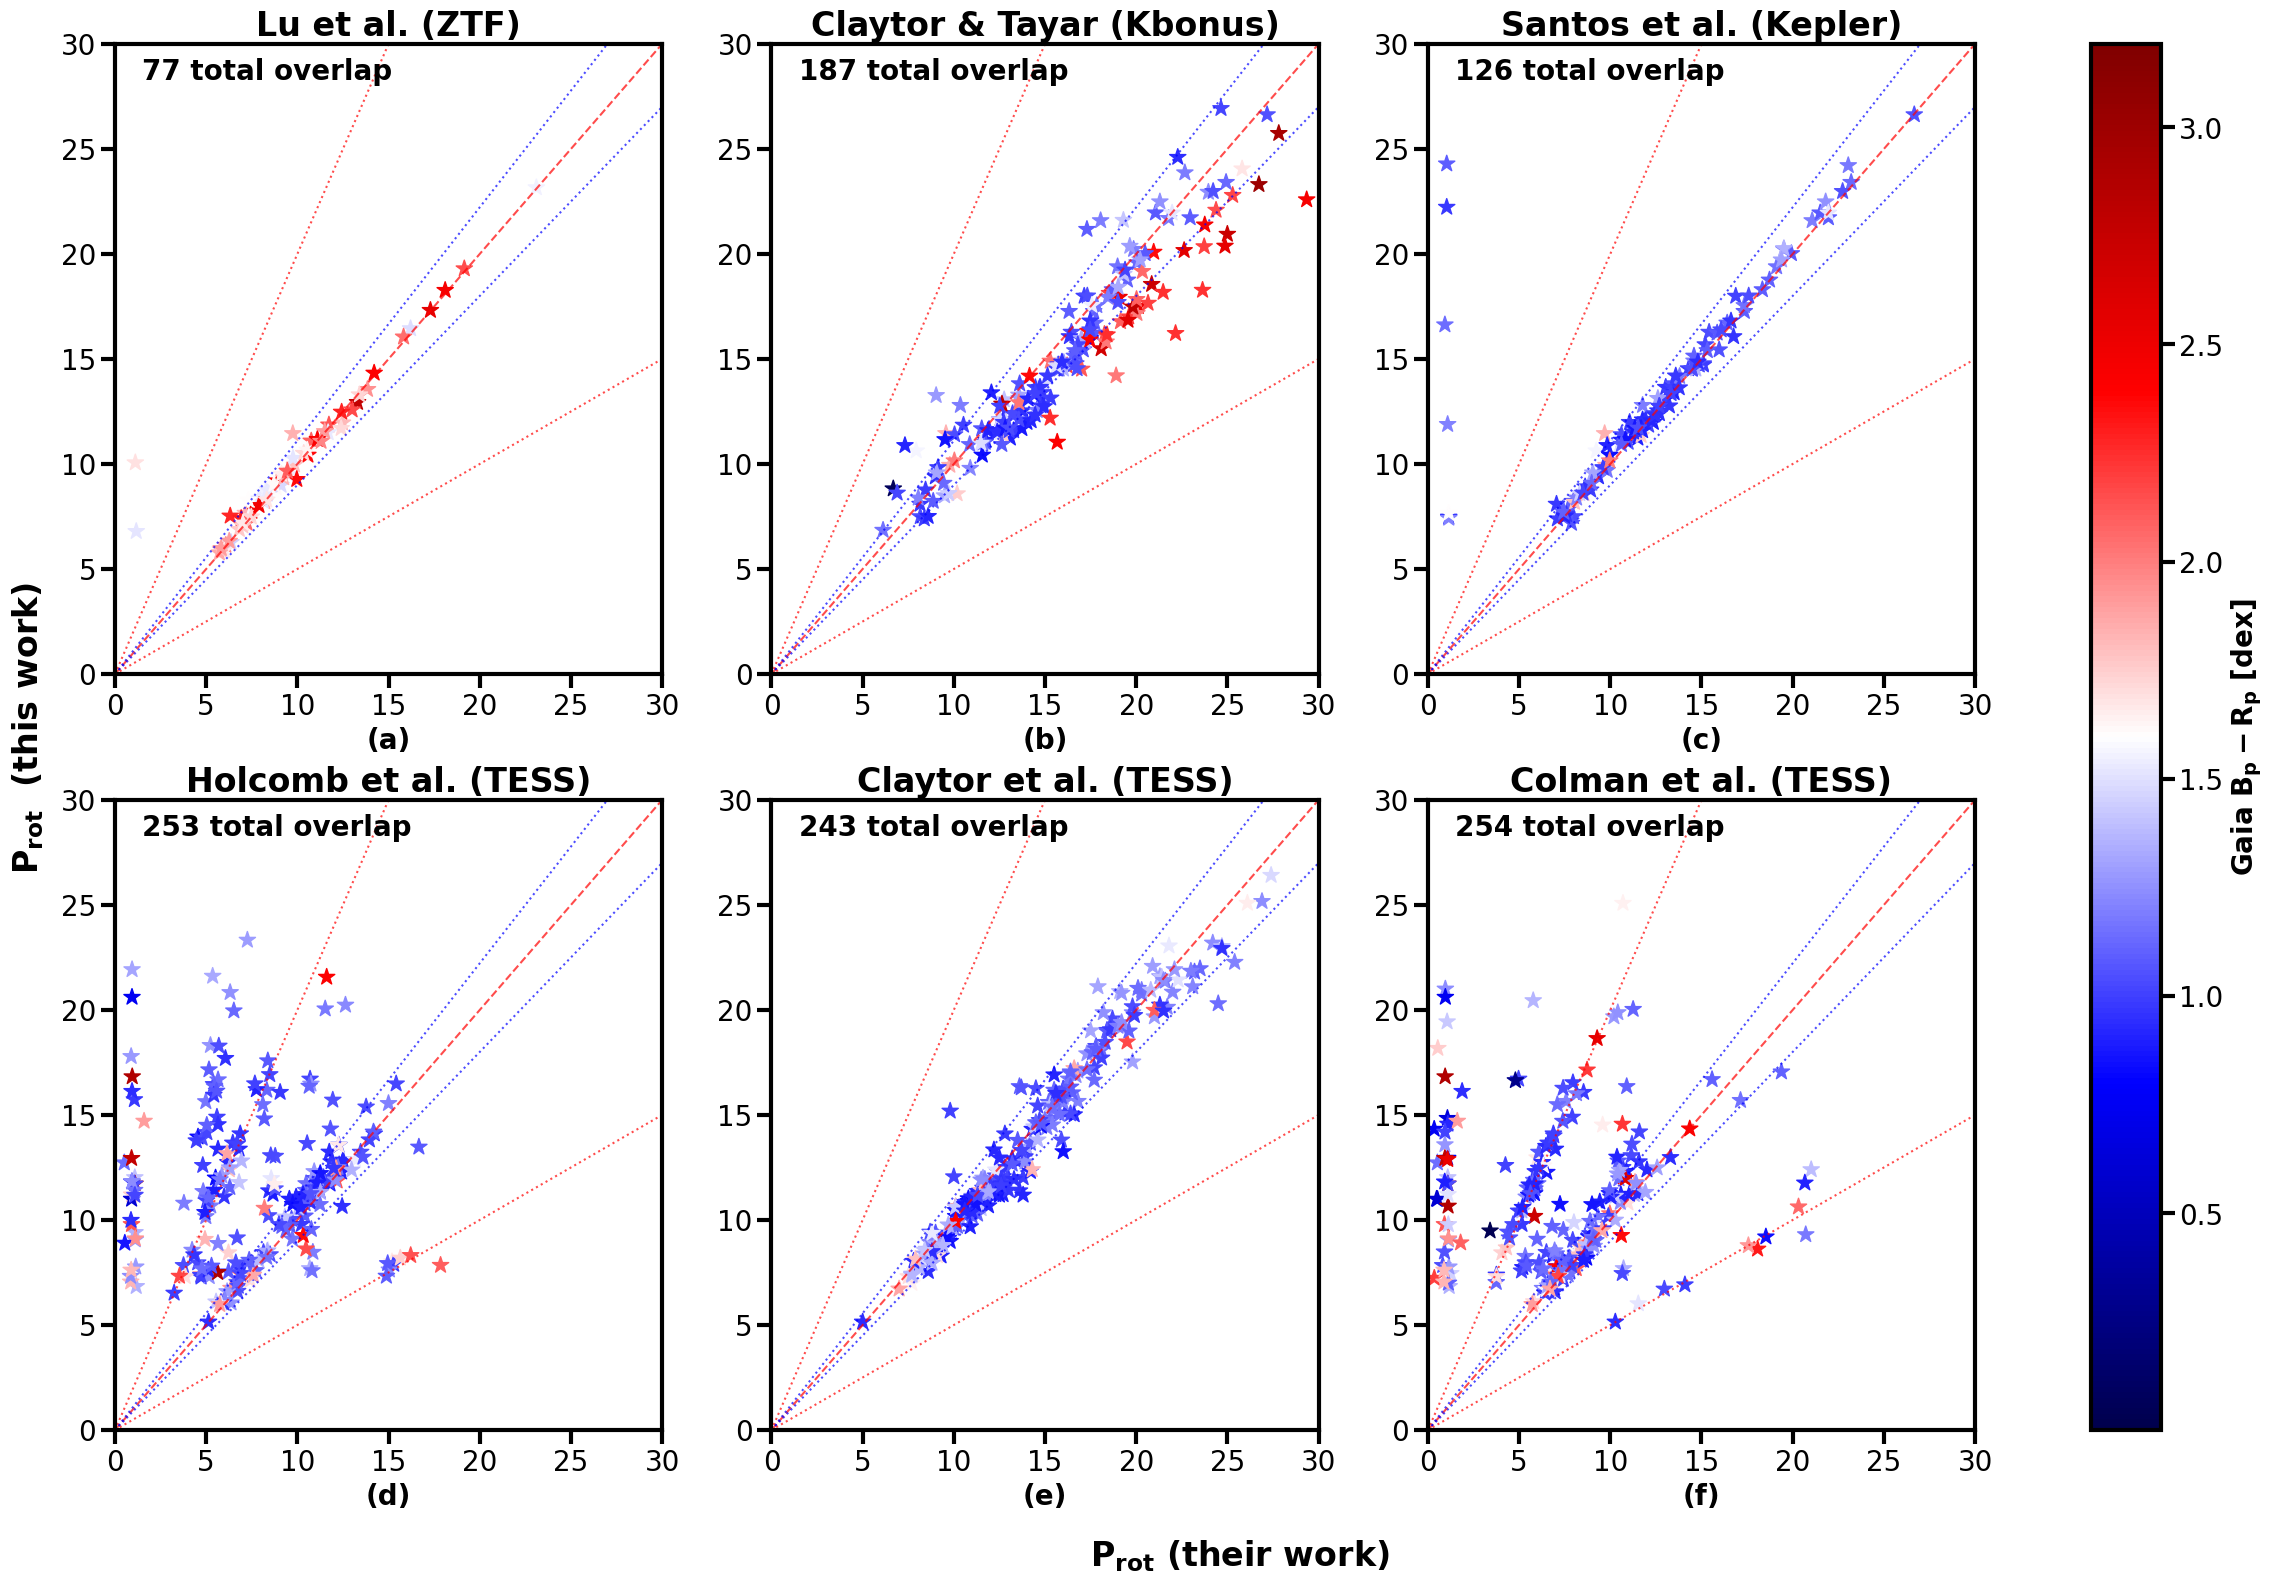

In [70]:
comparisons_plotter_6x(catalogs, parameter = 'bp-rp', save=True)